# Decoration, guides and named camera views

Furniture that frames a scene and explains its colours:

- **Decoration** — `coastlines()` / `borders()` (Natural-Earth reference lines), `text()` labels,
  `axes()` / `orientation_axes()` bounding furniture, `set_title()`.
- **Guides** — `colorbar()` (a continuous scalar key) and `legend()` (a keyed class list).
- **Camera** — `view()` snaps to a named viewpoint (`top`, `front`, `isometric`, …).

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from digitalearth.base.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()
import geopandas as gpd
from shapely.geometry import Polygon
from pyramids.dataset import Dataset

## `coastlines()` and `borders()` — Natural-Earth reference lines

In a flat (non-globe) scene, these draw world reference geography as their own layers.

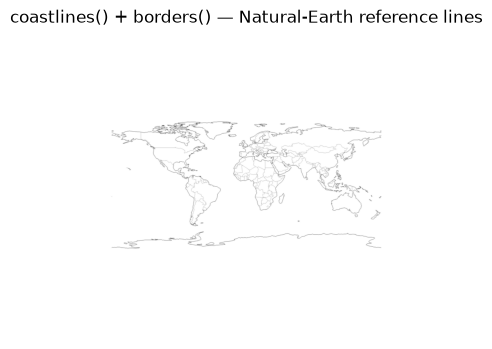

In [2]:
scene = Scene3D(off_screen=True)
scene.coastlines(color='black')
scene.borders(color='#888888')
scene.view('top')
show(scene, 'coastlines() + borders() — Natural-Earth reference lines')
scene.close()

## `text()` — a label at a coordinate

Labels are placed at a `(lon, lat)` and registered as their own layer.

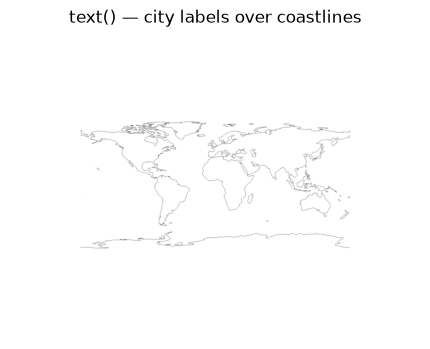

In [3]:
scene = Scene3D(off_screen=True)
scene.coastlines(color='black')
scene.text(-0.13, 51.5, 'London', text_size=16, color='crimson')
scene.text(2.35, 48.85, 'Paris', text_size=16, color='navy')
scene.view('top')
show(scene, 'text() — city labels over coastlines')
scene.close()

## `axes()`, `orientation_axes()`, `set_title()` — framing furniture

A titled, bounded terrain with a corner orientation triad.

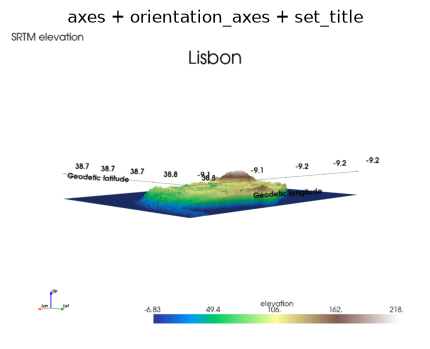

In [4]:
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, cmap='terrain')
scene.axes(show=True)
scene.orientation_axes(show=True)
scene.set_title('Lisbon', subtitle='SRTM elevation')
show(scene, 'axes + orientation_axes + set_title')
scene.close()

## `colorbar()` — a continuous scalar key

Label the elevation ramp of a terrain.

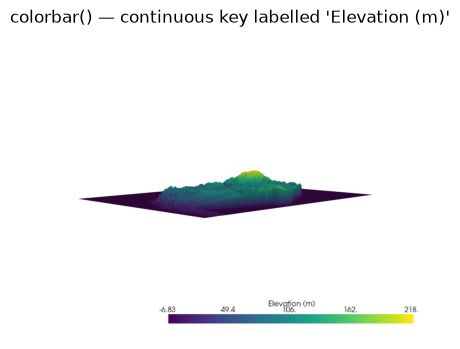

In [5]:
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, cmap='viridis')
scene.colorbar(label='Elevation (m)')
show(scene, "colorbar() — continuous key labelled 'Elevation (m)'")
scene.close()

## `legend()` — a keyed class list

For a *classified* layer (here a quantile choropleth), `legend()` draws a keyed box.

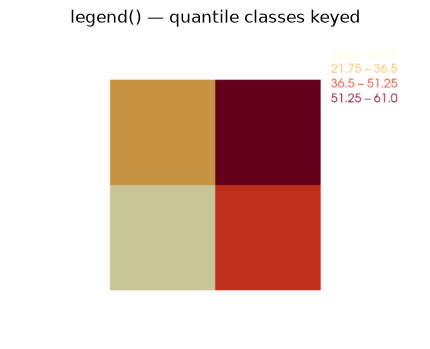

In [6]:
zones = gpd.GeoDataFrame(
    {'population': [12.0, 48.0, 25.0, 61.0]},
    geometry=[
        Polygon([(0, 0), (1, 0), (1, 1), (0, 1)]),
        Polygon([(1, 0), (2, 0), (2, 1), (1, 1)]),
        Polygon([(0, 1), (1, 1), (1, 2), (0, 2)]),
        Polygon([(1, 1), (2, 1), (2, 2), (1, 2)]),
    ],
)
scene = Scene3D(off_screen=True)
scene.choropleth(zones, column='population', scheme='quantiles', k=4, cmap='YlOrRd')
scene.legend(title='Population')
scene.view('top')
show(scene, 'legend() — quantile classes keyed')
scene.close()

## `view()` — named camera viewpoints

The shipped views are `back, bottom, front, isometric, left, right, top`.

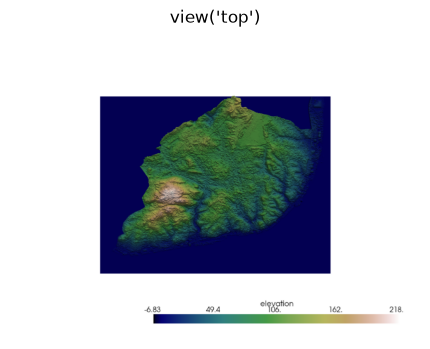

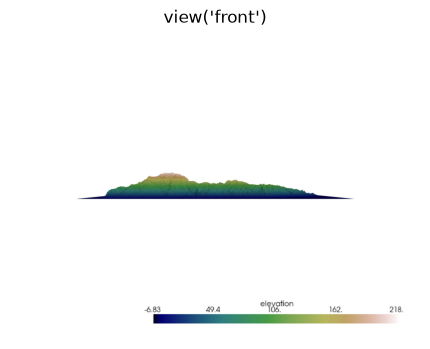

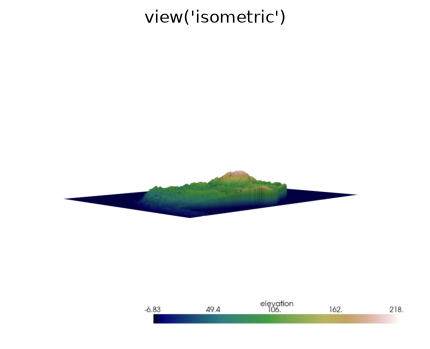

In [7]:
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
for name in ('top', 'front', 'isometric'):
    scene = Scene3D(off_screen=True)
    scene.terrain(dem, z_exaggeration=8.0, cmap='gist_earth')
    scene.view(name)
    show(scene, f"view('{name}')")
    scene.close()